In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\ev_charging_cleaned.csv")

C:\Users\loneo\AppData\Local\Temp\ipykernel_18972\640505923.py:1: DtypeWarning: Columns (0: User ID, 1: County, 2: Model Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\ev_charging_cleaned.csv")


In [24]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Transaction Date (Pacific Time)'] = pd.to_datetime(df['Transaction Date (Pacific Time)'])

df['Total Duration (hh:mm:ss)'] = pd.to_timedelta(df['Total Duration (hh:mm:ss)'])

df['Charging Time (hh:mm:ss)'] = pd.to_timedelta(df['Charging Time (hh:mm:ss)'])

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259366 entries, 0 to 259365
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype          
---  ------                           --------------   -----          
 0   Station Name                     259366 non-null  str            
 1   MAC Address                      259366 non-null  str            
 2   Org Name                         259366 non-null  str            
 3   Start Date                       259366 non-null  datetime64[us] 
 4   Start Time Zone                  259366 non-null  str            
 5   End Date                         259366 non-null  datetime64[us] 
 6   End Time Zone                    259366 non-null  str            
 7   Transaction Date (Pacific Time)  259157 non-null  datetime64[us] 
 8   Total Duration (hh:mm:ss)        259366 non-null  timedelta64[us]
 9   Charging Time (hh:mm:ss)         259366 non-null  timedelta64[us]
 10  Energy (kWh)                     259366 non

In [28]:
df['Start Date'].min()

Timestamp('2011-07-29 20:17:00')

In [30]:
df['Start Date Year'] = pd.to_datetime(df['Start Date']).dt.year
df['Start Date Month'] = pd.to_datetime(df['Start Date']).dt.month
df['Start Date Date'] = pd.to_datetime(df['Start Date']).dt.date
df['Start Date Hour'] = pd.to_datetime(df['Start Date']).dt.hour
df['Start Date Dayofweek'] = pd.to_datetime(df['Start Date']).dt.dayofweek

session per year


In [33]:
df

,Station Name,MAC Address,Org Name,Start Date,Start Time Zone,End Date,End Time Zone,Transaction Date (Pacific Time),Total Duration (hh:mm:ss),Charging Time (hh:mm:ss),...,Driver Postal Code,User ID,County,System S/N,Model Number,Start Date Year,Start Date Month,Start Date Date,Start Date Hour,Start Date Dayofweek
0,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-29 20:17:00,PDT,2011-07-29 23:20:00,PDT,2011-07-29 23:20:00,0 days 03:03:32,0 days 01:54:03,...,95124.0,3284.0,NaN,NaN,NaN,2011,7,2011-07-29,20,4
1,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-30 00:00:00,PDT,2011-07-30 00:02:00,PDT,2011-07-30 00:02:00,0 days 00:02:06,0 days 00:01:54,...,94301.0,4169.0,NaN,NaN,NaN,2011,7,2011-07-30,0,5
2,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-30 08:16:00,PDT,2011-07-30 12:34:00,PDT,2011-07-30 12:34:00,0 days 04:17:32,0 days 04:17:28,...,94301.0,4169.0,NaN,NaN,NaN,2011,7,2011-07-30,8,5
3,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-30 14:51:00,PDT,2011-07-30 16:55:00,PDT,2011-07-30 16:55:00,0 days 02:03:24,0 days 02:02:58,...,94302.0,2545.0,NaN,NaN,NaN,2011,7,2011-07-30,14,5
4,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-30 18:51:00,PDT,2011-07-30 20:03:00,PDT,2011-07-30 20:03:00,0 days 01:11:24,0 days 00:43:54,...,94043.0,3765.0,NaN,NaN,NaN,2011,7,2011-07-30,18,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259361,PALO ALTO CA / TED THOMPSON #3,0024:B100:0002:9F81,City of Palo Alto,2020-12-31 16:39:00,PST,2020-12-31 17:14:00,PST,2020-12-31 17:16:00,0 days 00:35:44,0 days 00:35:18,...,94301.0,2024201,NaN,1.745410e+11,CT4020-HD-GW,2020,12,2020-12-31,16,3
259362,PALO ALTO CA / WEBSTER #1,0024:B100:0002:4233,City of Palo Alto,2020-12-31 16:48:00,PST,2020-12-31 20:31:00,PST,2020-12-31 20:32:00,0 days 03:43:01,0 days 02:14:04,...,94541.0,242661,Santa Clara County,1.336410e+11,CT4020-HD-GW,2020,12,2020-12-31,16,3
259363,PALO ALTO CA / MPL #4,0024:B100:0003:CD37,City of Palo Alto,2020-12-31 17:28:00,PST,2021-01-01 10:56:00,PST,2021-01-01 10:57:00,0 days 17:28:14,0 days 05:08:12,...,94306.0,449995,Santa Clara County,2.002410e+11,CT4010-HD-GW,2020,12,2020-12-31,17,3
259364,PALO ALTO CA / WEBSTER #1,0024:B100:0002:4233,City of Palo Alto,2020-12-31 17:49:00,PST,2020-12-31 21:55:00,PST,2020-12-31 21:56:00,0 days 04:05:34,0 days 03:53:42,...,94552.0,804075,Santa Clara County,1.336410e+11,CT4020-HD-GW,2020,12,2020-12-31,17,3


<Axes: xlabel='Start Date Year'>

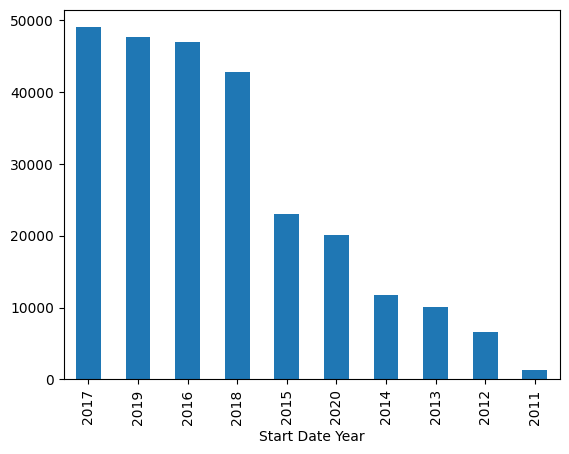

In [35]:
df['Start Date Year'].value_counts().plot(kind='bar')

In [36]:
df['Start Date Year'].value_counts()

Start Date Year
2017    49011
2019    47731
2016    46931
2018    42803
2015    23104
2020    20094
2014    11720
2013    10098
2012     6600
2011     1274
Name: count, dtype: int64

In [39]:
df['Start Date Month'].value_counts()

Start Date Month
1     22974
10    22956
3     22151
2     22087
5     21896
8     21629
7     21449
11    21393
6     21299
9     20981
12    20752
4     19799
Name: count, dtype: int64

<Axes: xlabel='Start Date Month'>

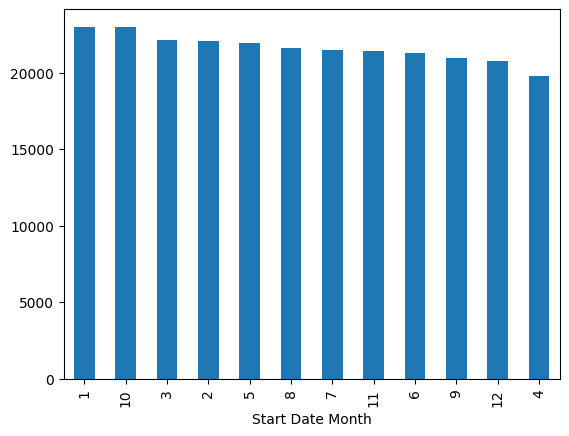

In [41]:
df['Start Date Month'].value_counts().plot(kind='bar')

In [42]:


df.groupby('Start Date Year')['Start Date Month'].value_counts().sort_index()

Start Date Year  Start Date Month
2011             7                      9
                 8                    137
                 9                    178
                 10                   294
                 11                   311
                                     ... 
2020             8                   1177
                 9                   1228
                 10                  1495
                 11                  1192
                 12                  1020
Name: count, Length: 114, dtype: int64

<Axes: xlabel='Start Date Year,Start Date Month'>

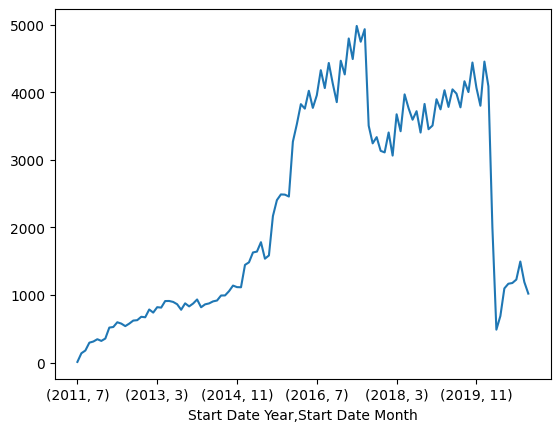

In [45]:
df.groupby('Start Date Year')['Start Date Month'].value_counts().sort_index().plot()

In [46]:
df['Start Date Date'].value_counts().sort_index()


Start Date Date
2011-07-29     1
2011-07-30     5
2011-07-31     3
2011-08-01     1
2011-08-02     3
              ..
2020-12-27    26
2020-12-28    29
2020-12-29    35
2020-12-30    27
2020-12-31    25
Name: count, Length: 3444, dtype: int64

<Axes: xlabel='Start Date Date'>

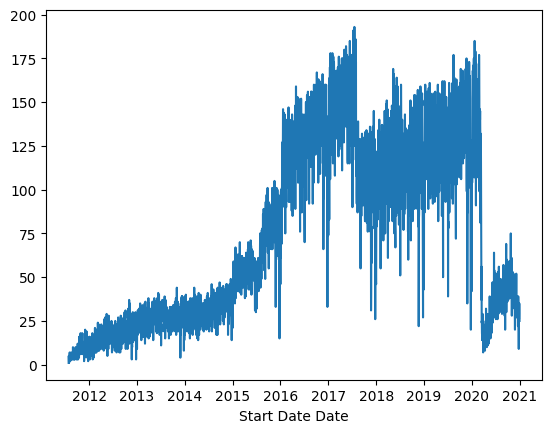

In [49]:
df['Start Date Date'].value_counts().sort_index().plot()

In [50]:
df.head(3)

,Station Name,MAC Address,Org Name,Start Date,Start Time Zone,End Date,End Time Zone,Transaction Date (Pacific Time),Total Duration (hh:mm:ss),Charging Time (hh:mm:ss),...,Driver Postal Code,User ID,County,System S/N,Model Number,Start Date Year,Start Date Month,Start Date Date,Start Date Hour,Start Date Dayofweek
0,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-29 20:17:00,PDT,2011-07-29 23:20:00,PDT,2011-07-29 23:20:00,0 days 03:03:32,0 days 01:54:03,...,95124.0,3284.0,NaN,NaN,NaN,2011,7,2011-07-29,20,4
1,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-30 00:00:00,PDT,2011-07-30 00:02:00,PDT,2011-07-30 00:02:00,0 days 00:02:06,0 days 00:01:54,...,94301.0,4169.0,NaN,NaN,NaN,2011,7,2011-07-30,0,5
2,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,2011-07-30 08:16:00,PDT,2011-07-30 12:34:00,PDT,2011-07-30 12:34:00,0 days 04:17:32,0 days 04:17:28,...,94301.0,4169.0,NaN,NaN,NaN,2011,7,2011-07-30,8,5


<Axes: xlabel='Start Date Date'>

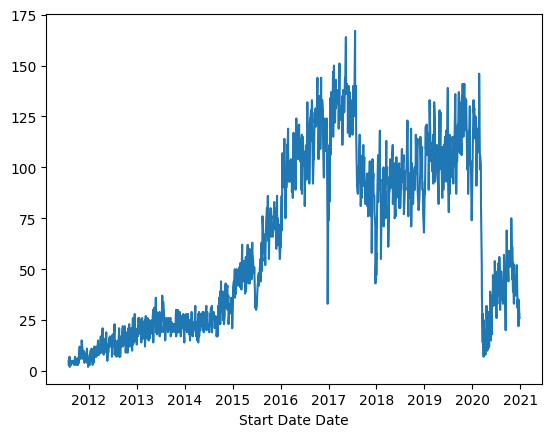

In [53]:
df[(df['Start Date Dayofweek'] == 5) | (df['Start Date Dayofweek'] == 6)]['Start Date Date'].value_counts().sort_index().plot()

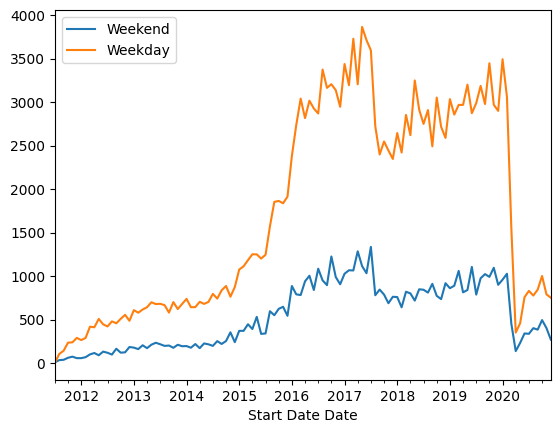

In [54]:
weekend = df[df['Start Date Dayofweek'].isin([5,6])].groupby('Start Date Date').size()
weekday = df[~df['Start Date Dayofweek'].isin([5,6])].groupby('Start Date Date').size()

weekend.index = pd.to_datetime(weekend.index)
weekday.index = pd.to_datetime(weekday.index)

weekend.resample('ME').sum().plot(label='Weekend')
weekday.resample('ME').sum().plot(label='Weekday')

plt.legend()
plt.show()

<Axes: xlabel='Start Date Date'>

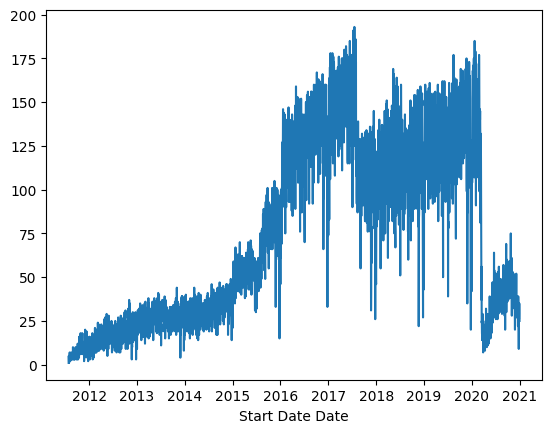

In [56]:
df['Start Date Date'].value_counts().sort_index().plot()

<Axes: xlabel='Start Date Hour'>

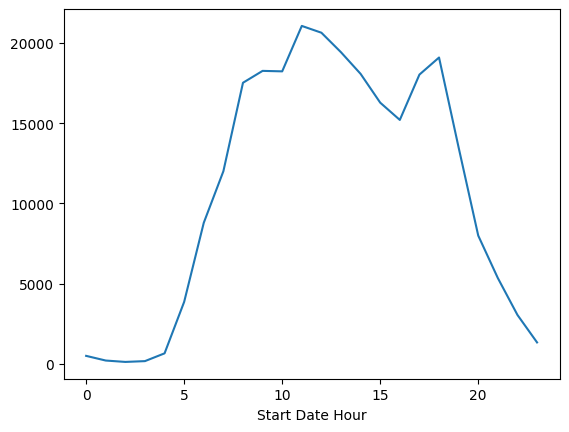

In [57]:
df['Start Date Hour'].value_counts().sort_index().plot()

In [58]:
top_hours = df['Start Date Hour'].value_counts().sort_values(ascending=False)
print(top_hours)

Start Date Hour
11    21057
12    20634
13    19417
18    19089
9     18257
10    18227
14    18070
17    18025
8     17517
15    16277
16    15202
19    13482
7     12005
6      8796
20     7997
21     5352
5      3871
22     3056
23     1343
4       663
0       506
1       215
3       179
2       129
Name: count, dtype: int64


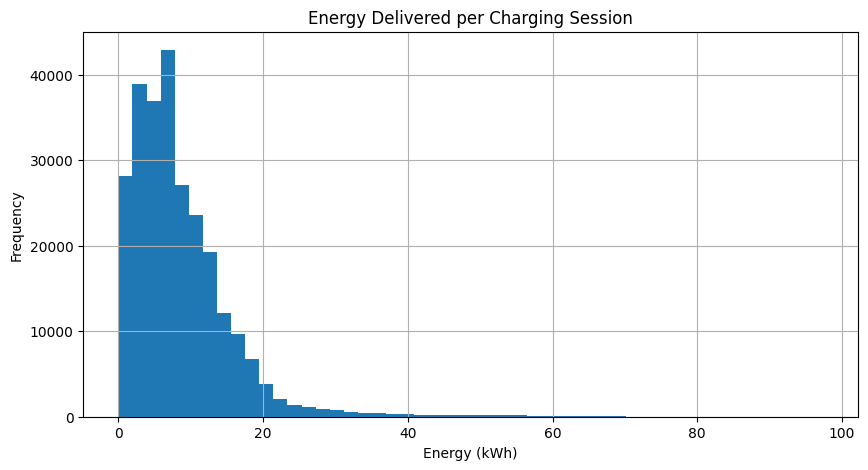

In [60]:
plt.figure(figsize=(10,5))
df['Energy (kWh)'].hist(bins=50)
plt.title('Energy Delivered per Charging Session')
plt.xlabel('Energy (kWh)')
plt.ylabel('Frequency')
plt.show()

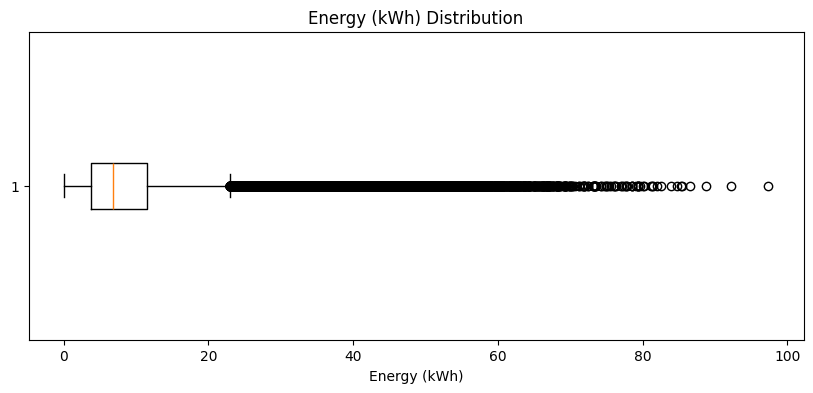

In [62]:
plt.figure(figsize=(10,4))
plt.boxplot(df['Energy (kWh)'], vert=False)
plt.title('Energy (kWh) Distribution')
plt.xlabel('Energy (kWh)')
plt.show()

In [65]:
df['Energy (kWh)'].describe()

count    259366.000000
mean          8.542094
std           7.178652
min           0.010000
25%           3.784000
50%           6.868000
75%          11.457000
max          97.360000
Name: Energy (kWh), dtype: float64

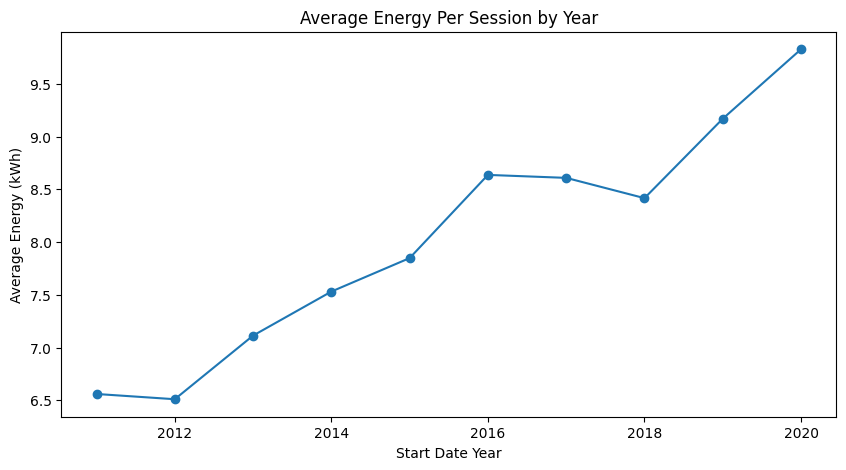

In [67]:
energy_per_session_year = (df.groupby('Start Date Year')['Energy (kWh)'].mean())

energy_per_session_year.plot(kind='line',marker='o',figsize=(10,5))

plt.title('Average Energy Per Session by Year')
plt.ylabel('Average Energy (kWh)')
plt.show()

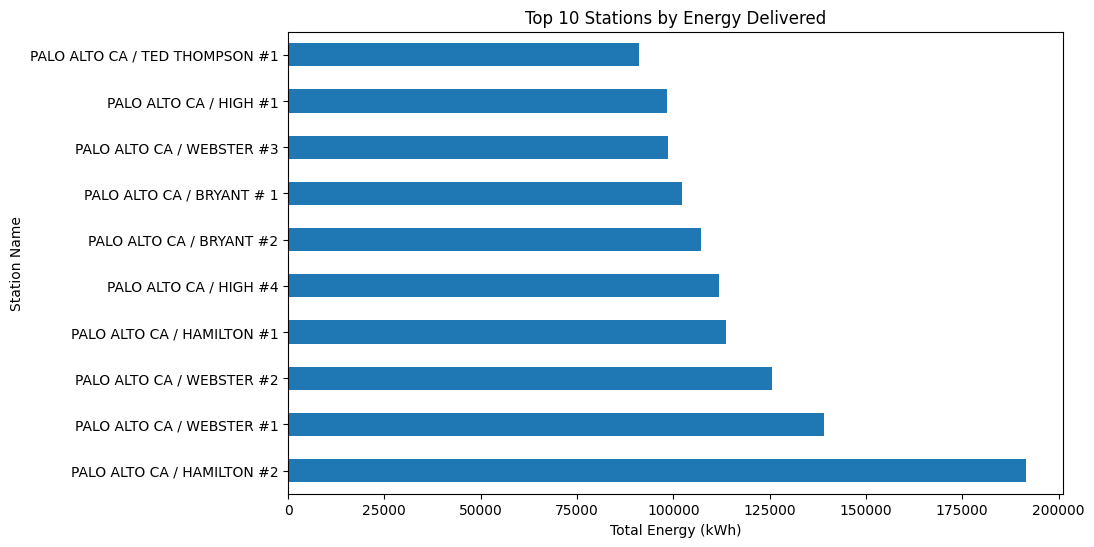

In [70]:
top_energy_stations = (df.groupby('Station Name')['Energy (kWh)'].sum().sort_values(ascending=False).head(10))

top_energy_stations.plot(kind='barh',figsize=(10,6))

plt.title('Top 10 Stations by Energy Delivered')
plt.xlabel('Total Energy (kWh)')
plt.show()

In [72]:
df[['Charging Time (hh:mm:ss)','Total Duration (hh:mm:ss)']].describe()

,Charging Time (hh:mm:ss),Total Duration (hh:mm:ss)
count,259366,259366
mean,0 days 01:59:55.072199,0 days 02:29:13.080827
std,0 days 01:22:53.304332,0 days 02:12:45.799495
min,0 days 00:00:06,0 days 00:01:00
25%,0 days 01:02:24,0 days 01:10:16
50%,0 days 01:48:59,0 days 02:05:22
75%,0 days 02:41:49.750000,0 days 03:05:25
max,0 days 22:55:55,4 days 18:32:21


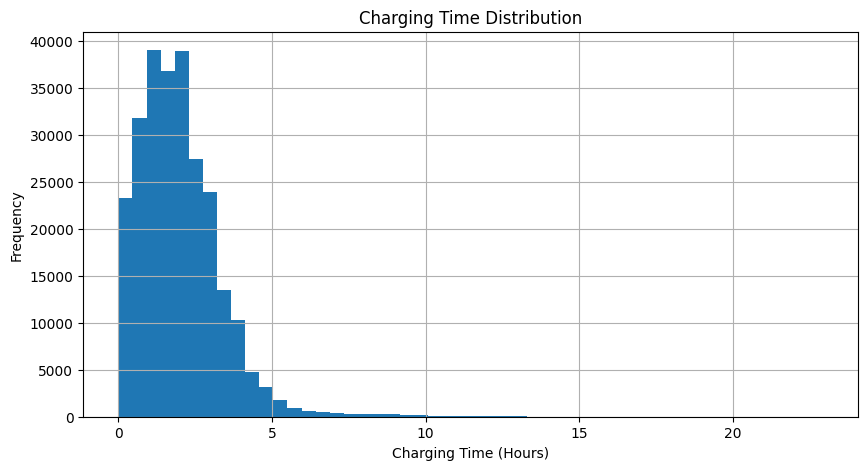

In [100]:
plt.figure(figsize=(10,5))
df['Charging Time (hh:mm:ss)'].dt.total_seconds().div(3600).hist(bins=50)
plt.title('Charging Time Distribution')
plt.xlabel('Charging Time (Hours)')
plt.ylabel('Frequency')
plt.show()


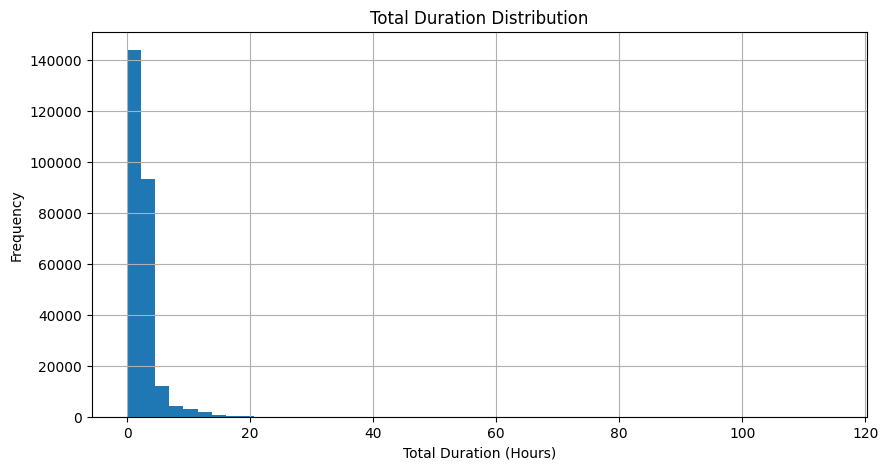

In [102]:
plt.figure(figsize=(10,5))
df['Total Duration (hh:mm:ss)'].dt.total_seconds().div(3600).hist(bins=50)
plt.title('Total Duration Distribution')
plt.xlabel('Total Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

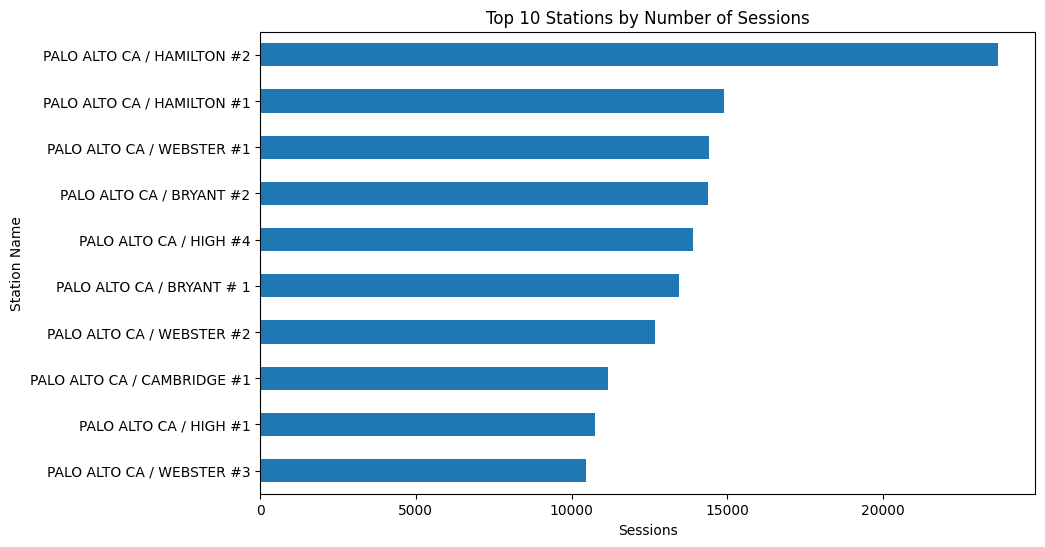

In [104]:
top_stations = (df['Station Name'].value_counts().head(10))

top_stations.sort_values().plot(kind='barh',figsize=(10,6))

plt.title('Top 10 Stations by Number of Sessions')
plt.xlabel('Sessions')
plt.show()

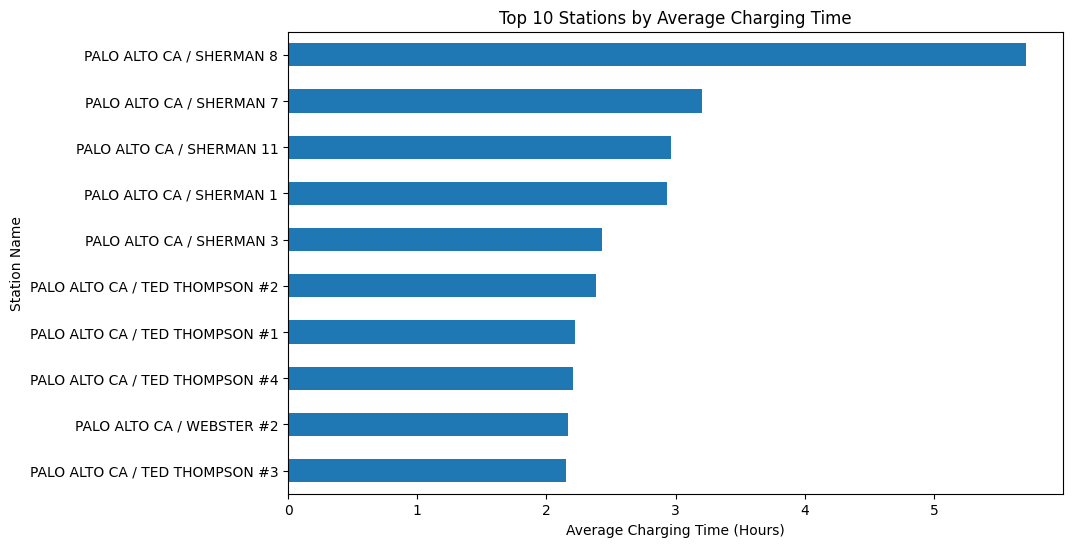

In [112]:
avg_duration_station = (df.groupby('Station Name')['Charging Time (hh:mm:ss)'].mean().dt.total_seconds().div(3600).sort_values(ascending=False).head(10))

avg_duration_station.sort_values().plot(kind='barh',figsize=(10,6))

plt.title('Top 10 Stations by Average Charging Time')
plt.xlabel('Average Charging Time (Hours)')
plt.show()

In [108]:
station_summary = df.groupby('Station Name').agg({'Energy (kWh)': ['count','mean','sum'],'Charging Time (hh:mm:ss)': 'mean'})

In [110]:
station_summary

Energy (kWh)                            \
                                      count       mean            sum   
Station Name                                                            
PALO ALTO CA / BRYANT # 1             13447   7.611354  102349.877624   
PALO ALTO CA / BRYANT #2              14381   7.455704  107220.474039   
PALO ALTO CA / BRYANT #3               4472   8.632309   38603.686866   
PALO ALTO CA / BRYANT #4               3597  10.339060   37189.600000   
PALO ALTO CA / BRYANT #5               5329   9.138810   48700.719000   
PALO ALTO CA / BRYANT #6               5857   9.042089   52959.513000   
PALO ALTO CA / CAMBRIDGE #1           11162   7.212398   80504.781129   
PALO ALTO CA / CAMBRIDGE #2            9256   6.979861   64605.595250   
PALO ALTO CA / CAMBRIDGE #3            4476   6.953960   31125.926000   
PALO ALTO CA / CAMBRIDGE #4            3428   7.261479   24892.351000   
PALO ALTO CA / CAMBRIDGE #5            4556   7.391510   33675.721000   
PALO ALTO CA / HAMILTON #1            14886   7.637761  113695.712588   
PALO ALTO CA / HAMILTON #2            23715   8.078969  191592.759570   
PALO ALTO CA / HIGH #1                10755   9.147141   98377.502769   
PALO ALTO CA / HIGH #2                 6928   8.994006   62310.477000   
PALO ALTO CA / HIGH #3                 8317   8.882436   73875.224000   
PALO ALTO CA / HIGH #4                13895   8.049540  111848.360222   
PALO ALTO CA / MPL #1                  1044   8.623077    9002.491923   
PALO ALTO CA / MPL #2                  1531   8.847008   13544.769855   
PALO ALTO CA / MPL #3                  1420   8.425539   11964.265757   
PALO ALTO CA / MPL #4                  7787   8.568404   66722.158095   
PALO ALTO CA / MPL #5                  7544   8.687256   65536.659778   
PALO ALTO CA / MPL #6                  8994   8.680762   78074.775167   
PALO ALTO CA / RINCONADA LIB 1         6211   9.492754   58959.496408   
PALO ALTO CA / RINCONADA LIB 2         5551   9.494758   52705.403935   
PALO ALTO CA / RINCONADA LIB 3         6499   9.229214   59980.658975   
PALO ALTO CA / SHERMAN 1                  7  16.041000     112.287000   
PALO ALTO CA / SHERMAN 11                 1  17.154000      17.154000   
PALO ALTO CA / SHERMAN 14                 2   9.159500      18.319000   
PALO ALTO CA / SHERMAN 15                 1  10.951000      10.951000   
PALO ALTO CA / SHERMAN 17                 1   6.776000       6.776000   
PALO ALTO CA / SHERMAN 2                  4  10.400000      41.600000   
PALO ALTO CA / SHERMAN 3                  8  12.825000     102.600000   
PALO ALTO CA / SHERMAN 4                  4   5.745250      22.981000   
PALO ALTO CA / SHERMAN 5                  1   2.921000       2.921000   
PALO ALTO CA / SHERMAN 6                  3  11.213333      33.640000   
PALO ALTO CA / SHERMAN 7                  4  19.618250      78.473000   
PALO ALTO CA / SHERMAN 8                  2  33.612000      67.224000   
PALO ALTO CA / SHERMAN 9                  1   4.906000       4.906000   
PALO ALTO CA / TED THOMPSON #1         9814   9.289575   91167.889604   
PALO ALTO CA / TED THOMPSON #2         2217  11.194210   24817.564000   
PALO ALTO CA / TED THOMPSON #3         2455   9.824646   24119.506000   
PALO ALTO CA / TED THOMPSON #4         2226   9.694355   21579.634000   
PALO ALTO CA / WEBSTER #1             14429   9.636625  139046.854988   
PALO ALTO CA / WEBSTER #2             12667   9.924733  125716.591951   
PALO ALTO CA / WEBSTER #3             10481   9.401952   98541.854563   

                               Charging Time (hh:mm:ss)  
                                                   mean  
Station Name                                             
PALO ALTO CA / BRYANT # 1        0 days 02:04:16.520041  
PALO ALTO CA / BRYANT #2         0 days 02:00:06.242681  
PALO ALTO CA / BRYANT #3         0 days 02:00:08.580053  
PALO ALTO CA / BRYANT #4         0 days 02:08:33.140672  
PALO ALTO CA / BRYANT #5         0 days 01:57:2